# Data Exploration, Cleaning
### Customer Support Call — Issue Classification Dataset

This notebook walks through everything we need before fine-tuning:

1. Loading the raw train and test datasets
2. Exploratory data analysis (EDA)
3. Data quality checks and cleaning


---

## 1. Libraries

In [40]:
# Uncomment and run this cell once if any package is missing
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. The `styled()` Helper

We use this function throughout the notebook to display DataFrames and Series in a clean, left-aligned table style. The `dots=True` mode shows just the first 3 and last 3 rows for large tables, which is much easier to read than scrolling through hundreds of rows.

In [42]:
def styled(obj, caption="", dots=False):
    if isinstance(obj, pd.Series):
        obj = obj.to_frame().T

    if dots and isinstance(obj, pd.DataFrame) and len(obj) > 6:
        head = obj.head(3)
        tail = obj.tail(3)
        ellipsis_row = pd.DataFrame([['...'] * obj.shape[1]], columns=obj.columns)
        ellipsis_row.index = ['...']
        obj = pd.concat([head, ellipsis_row, tail])

    return (
        obj.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': '.row_heading', 'props': [('text-align', 'left')]}
        ])
        .set_caption(caption)
    )

---
## 3. Load the Raw Datasets

We start by loading `train.csv` and `test.csv`. Each file has two columns: `text` (the customer sentence) and `category` (the issue label).

In [43]:
train_df = pd.read_csv('../data/train_augmented.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'Columns     : {train_df.columns.tolist()}')

Train shape : (10772, 2)
Test  shape : (3080, 2)
Columns     : ['text', 'category']


Let's take a quick look at the first few rows to make sure everything loaded correctly.

In [44]:
styled(train_df.head(10), caption="Training data — first 10 rows")

,text,category
0,Where do I go to verify my identity?,verify_my_identity
1,My new card hasn't came in.,card_arrival
2,Can I possibly change my currency to another?,exchange_via_app
3,There are a couple payments with my card in the app I see that I didn't create. What is happening? Maybe someone gained access to my account.,card_payment_not_recognised
4,I thought crypto top up with something you offered and it does not appear that it's working even though the money has disappeared out of my account. Can you tell me what's going on?,top_up_reverted
5,"My account shows I have been charged twice for the same meal. How do I get the second payment voided and returned to me? I do not eat out much and my family is living paycheck to paycheck, mostly. I cannot afford to spend more money than necessary, as is, so I must see to it that the cost be promptly credited back onto my card.",transaction_charged_twice
6,What do I do to link my new card?,card_linking
7,This disposable virtual card is not working.,virtual_card_not_working
8,I was overcharged a pound.,extra_charge_on_statement
9,What is the purpose for verifying my identity?,why_verify_identity


In [45]:
styled(test_df.head(10), caption="Test data — first 10 rows")

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I ordered over a week ago.",card_arrival
2,I ordered a card but it has not arrived. Help please!,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
5,When will I get my card?,card_arrival
6,Do you know if there is a tracking number for the new card you sent me?,card_arrival
7,i have not received my card,card_arrival
8,still waiting on that card,card_arrival
9,Is it normal to have to wait over a week for my new card?,card_arrival


---
## 4. Basic Statistics

Before doing anything else, it's good practice to get a feel for the size and shape of the data. Here we look at sample counts, number of unique categories, and sentence length statistics.

In [46]:
stats = pd.DataFrame({
    'Metric': [
        'Total samples',
        'Unique categories',
        'Avg text length (chars)',
        'Min text length (chars)',
        'Max text length (chars)',
        'Avg word count'
    ],
    'Train': [
        len(train_df),
        train_df['category'].nunique(),
        round(train_df['text'].str.len().mean(), 1),
        train_df['text'].str.len().min(),
        train_df['text'].str.len().max(),
        round(train_df['text'].str.split().str.len().mean(), 1)
    ],
    'Test': [
        len(test_df),
        test_df['category'].nunique(),
        round(test_df['text'].str.len().mean(), 1),
        test_df['text'].str.len().min(),
        test_df['text'].str.len().max(),
        round(test_df['text'].str.split().str.len().mean(), 1)
    ]
})

styled(stats, caption="Dataset basic statistics")

,Metric,Train,Test
0,Total samples,10772.000000,3080.000000
1,Unique categories,78.000000,77.000000
2,Avg text length (chars),58.200000,54.200000
3,Min text length (chars),3.000000,13.000000
4,Max text length (chars),429.000000,368.000000
5,Avg word count,11.700000,11.000000


In [47]:
categories = sorted(train_df['category'].unique())
cat_df = pd.DataFrame({'#': range(1, len(categories)+1), 'Category': categories})
styled(cat_df, caption=f"All {len(categories)} categories in the dataset", dots=True)

,#,Category
0,1,Refund_not_showing_up
1,2,activate_my_card
2,3,age_limit
...,...,...
75,76,why_verify_identity
76,77,wrong_amount_of_cash_received
77,78,wrong_exchange_rate_for_cash_withdrawal


---
## 5. Data Quality Checks

Before we do anything with the data, we need to make sure it's clean. We check for null values, duplicate rows, and whether all test categories also appear in training. If a category exists in test but not train, the model will have never seen it during fine-tuning — that would be a serious problem.

In [48]:
# Check for null values in both datasets
null_check = pd.DataFrame({
    'Column': train_df.columns.tolist(),
    'Nulls in Train': train_df.isnull().sum().values,
    'Nulls in Test': test_df.isnull().sum().values
})

styled(null_check, caption="Null value check")

,Column,Nulls in Train,Nulls in Test
0,text,0,0
1,category,0,0


In [49]:
# Check for duplicate rows — both exact duplicates and duplicate text with possibly different labels
dup_check = pd.DataFrame({
    'Check': [
        'Full duplicate rows',
        'Duplicate text (same sentence, possibly different label)',
    ],
    'Train': [
        train_df.duplicated().sum(),
        train_df.duplicated(subset='text').sum(),
    ],
    'Test': [
        test_df.duplicated().sum(),
        test_df.duplicated(subset='text').sum(),
    ]
})

styled(dup_check, caption="Duplicate rows check")

,Check,Train,Test
0,Full duplicate rows,11,0
1,"Duplicate text (same sentence, possibly different label)",12,0


In [50]:
# show duplicate rows
dup_rows = train_df[train_df.duplicated(subset='text', keep=False)].sort_values('text')
styled(dup_rows, caption="Duplicate text rows in training set", dots=False)

,text,category
10446,Alright.,neutral
5705,Alright.,neutral
5539,Do I need to go to a physical bank to change my PIN?,change_pin
9962,Do I need to go to a physical bank to change my PIN?,change_pin
10292,How do I create a disposable virtual card?,get_disposable_virtual_card
9087,How do I create a disposable virtual card?,get_disposable_virtual_card
7961,I can't seem to be able to use my card,card_not_working
8755,I can't seem to be able to use my card,card_not_working
3808,I put the wrong pin too many times and now it is blocked. Can you help me unblock it?,pin_blocked
7843,I put the wrong pin too many times and now it is blocked. Can you help me unblock it?,pin_blocked


In [51]:
# remove duplicate text rows (keep the first occurrence)
train_df = train_df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
print(f"After removing duplicates, train shape: {train_df.shape}")
#remove duplicate text rows from test set as well (if any)
test_df = test_df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
# print count of duplicate text rows now
dup_check_after = pd.DataFrame({
    'Check': ['Duplicate text (same sentence, possibly different label) after removal'],
    'Train': [train_df.duplicated(subset='text').sum()],
    'Test': [test_df.duplicated(subset='text').sum()]
})
styled(dup_check_after, caption="Duplicate text check after removal")

After removing duplicates, train shape: (10760, 2)


,Check,Train,Test
0,"Duplicate text (same sentence, possibly different label) after removal",0,0


In [52]:
# Make sure every category in the test set also appears in training
train_cats = set(train_df['category'].unique())
test_cats  = set(test_df['category'].unique())
unseen     = test_cats - train_cats

if unseen:
    print(f'WARNING: {len(unseen)} test categories not seen in train:')
    print(unseen)
else:
    print('All test categories exist in training data — no unseen labels.')

All test categories exist in training data — no unseen labels.


In [53]:
# Flag any suspiciously short sentences — under 15 characters is likely noise
short_train = train_df[train_df['text'].str.len() < 15]
short_test  = test_df[test_df['text'].str.len() < 15]

print(f'Sentences shorter than 15 chars in train : {len(short_train)}')
print(f'Sentences shorter than 15 chars in test  : {len(short_test)}')

if len(short_train) > 0:
    styled(short_train, caption="Short sentences found in train")

Sentences shorter than 15 chars in train : 43
Sentences shorter than 15 chars in test  : 3


---
## 6. Data Cleaning

The data is already quite clean, but we apply a light normalization step. We strip whitespace, collapse multiple spaces, and remove non-ASCII characters. Importantly, we keep punctuation and casing because BERT was pretrained on natural text and benefits from both — stripping them would actually hurt classification performance.

In [54]:
def clean_text(text):
    """
    Light cleaning pipeline for customer support sentences.
    - Strips leading/trailing whitespace
    - Collapses multiple spaces into one
    - Removes non-ASCII characters (rare encoding noise)
    We keep punctuation and casing — BERT handles these
    well and they carry real meaning for intent detection.
    """
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text']  = test_df['text'].apply(clean_text)

# Drop any rows that became empty strings after cleaning
before_train = len(train_df)
before_test  = len(test_df)

train_df = train_df[train_df['text'].str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df['text'].str.len() > 0].reset_index(drop=True)

cleaning_result = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Before cleaning': [before_train, before_test],
    'After cleaning': [len(train_df), len(test_df)],
    'Rows removed': [before_train - len(train_df), before_test - len(test_df)]
})

styled(cleaning_result, caption="Cleaning result")

,Dataset,Before cleaning,After cleaning,Rows removed
0,Train,10760,10760,0
1,Test,3080,3080,0


---
## 7. Class Distribution Analysis

One of the most important things to understand about a classification dataset is how balanced the classes are. A heavily imbalanced dataset means the model will naturally favor majority classes during training. We need to know this now so we can apply the right fix — weighted loss — during fine-tuning.

In [55]:
train_counts = train_df['category'].value_counts()

imbalance_summary = pd.DataFrame({
    'Metric': [
        'Most common class',
        'Least common class',
        'Max samples',
        'Min samples',
        'Imbalance ratio (max / min)',
        'Mean samples per class',
        'Std samples per class',
        'Classes under 100 samples'
    ],
    'Value': [
        train_counts.idxmax(),
        train_counts.idxmin(),
        train_counts.max(),
        train_counts.min(),
        f'{train_counts.max() / train_counts.min():.1f}x',
        round(train_counts.mean(), 1),
        round(train_counts.std(), 1),
        (train_counts < 100).sum()
    ]
})

styled(imbalance_summary, caption="Class imbalance summary")

,Metric,Value
0,Most common class,card_payment_fee_charged
1,Least common class,neutral
2,Max samples,187
3,Min samples,117
4,Imbalance ratio (max / min),1.6x
5,Mean samples per class,137.900000
6,Std samples per class,21.700000
7,Classes under 100 samples,0


In [56]:
# These are the classes we need to watch closely during evaluation
# They will likely have lower F1 scores simply due to having fewer training examples
low_classes = train_counts[train_counts < 100].reset_index()
low_classes.columns = ['Category', 'Sample count']

styled(low_classes, caption="Classes with fewer than 100 samples — expect lower F1 scores here")

,Category,Sample count


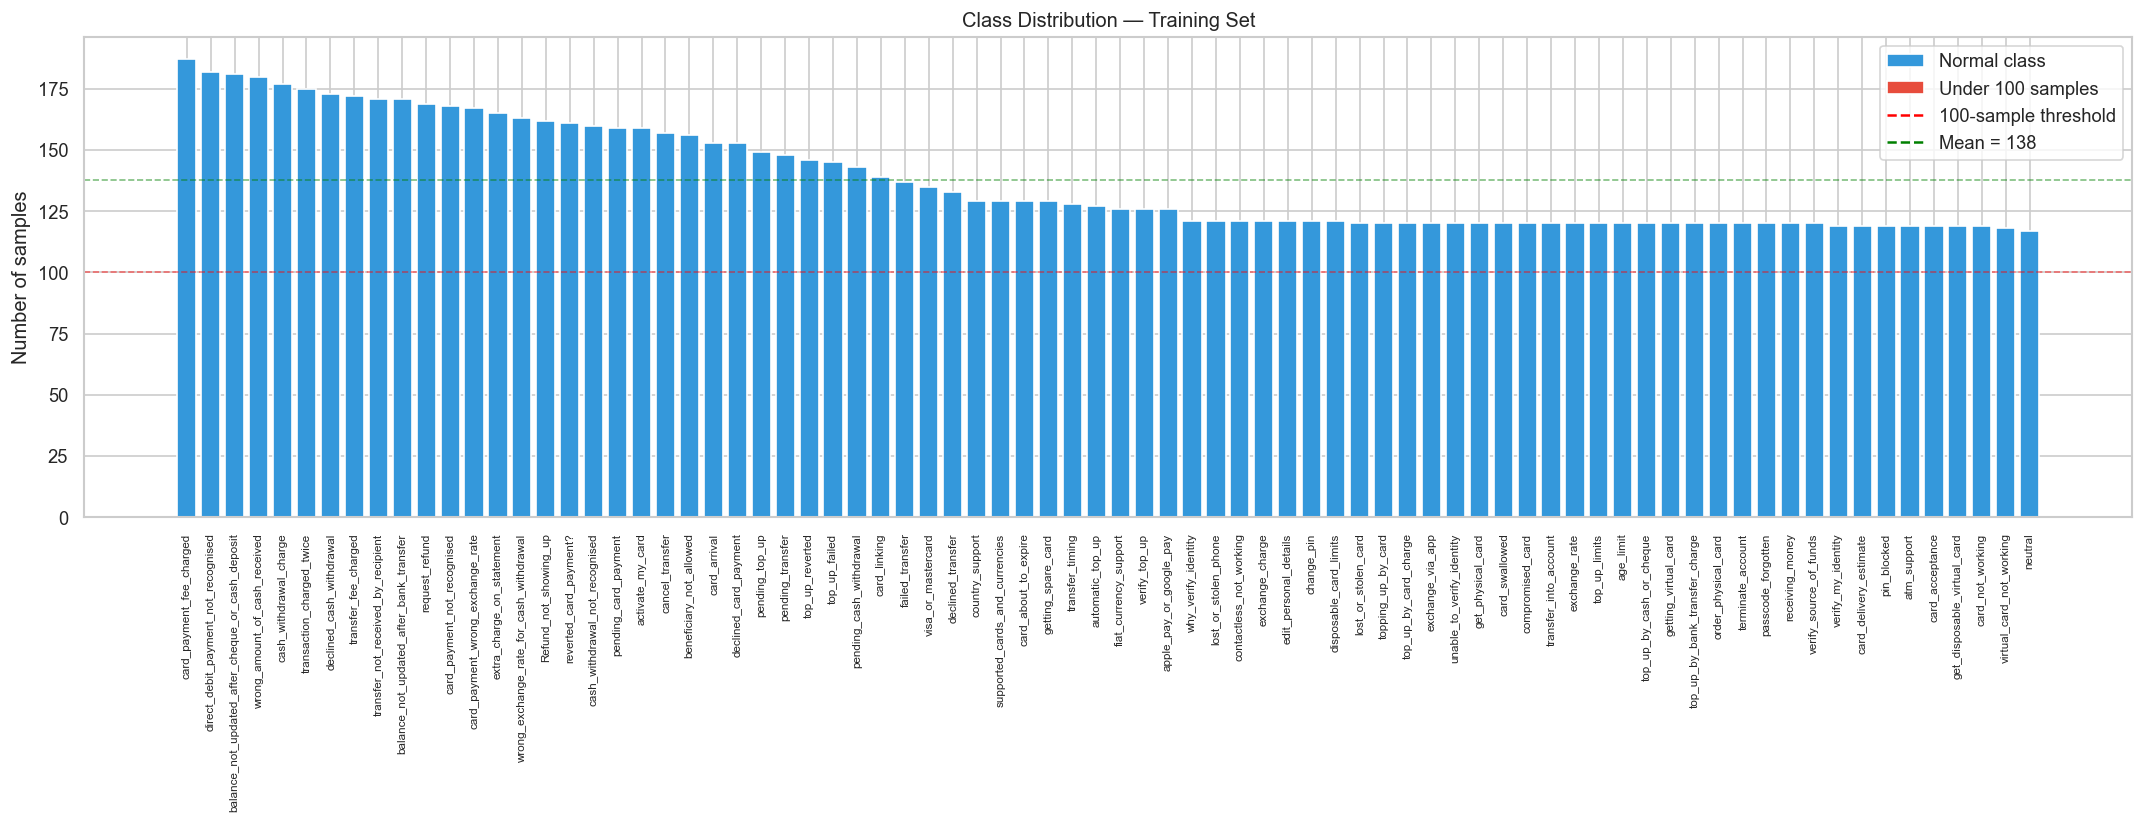

In [57]:
# Full class distribution — red bars are the classes we need to be careful about
fig, ax = plt.subplots(figsize=(18, 7))

colors = ['#e74c3c' if v < 100 else '#3498db' for v in train_counts.values]
ax.bar(range(len(train_counts)), train_counts.values, color=colors, width=0.8)
ax.set_xticks(range(len(train_counts)))
ax.set_xticklabels(train_counts.index, rotation=90, fontsize=7)
ax.set_ylabel('Number of samples')
ax.set_title('Class Distribution — Training Set')
ax.axhline(100, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(train_counts.mean(), color='green', linestyle='--', linewidth=1, alpha=0.5)

legend_elements = [
    mpatches.Patch(facecolor='#3498db', label='Normal class'),
    mpatches.Patch(facecolor='#e74c3c', label='Under 100 samples'),
    plt.Line2D([0],[0], color='red',   linestyle='--', label='100-sample threshold'),
    plt.Line2D([0],[0], color='green', linestyle='--', label=f'Mean = {train_counts.mean():.0f}'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

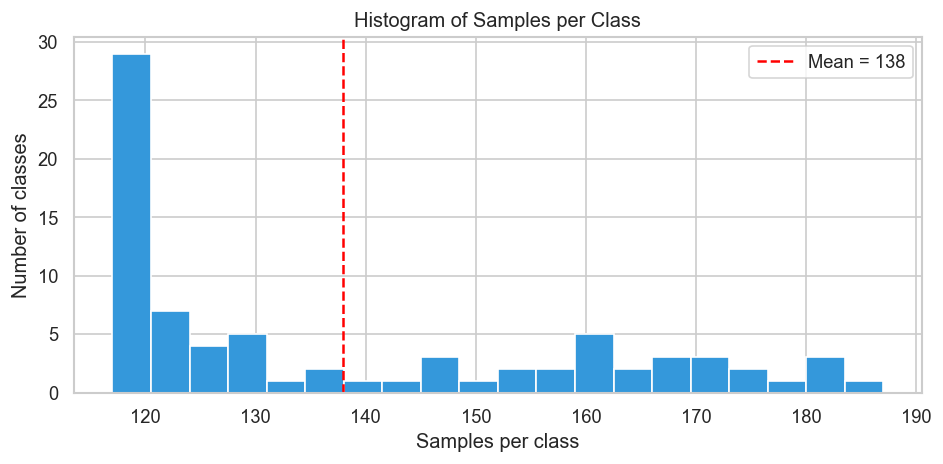

In [58]:
# This histogram gives a cleaner picture of how spread out the class sizes are
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_counts.values, bins=20, color='#3498db', edgecolor='white')
ax.axvline(train_counts.mean(), color='red', linestyle='--', label=f'Mean = {train_counts.mean():.0f}')
ax.set_xlabel('Samples per class')
ax.set_ylabel('Number of classes')
ax.set_title('Histogram of Samples per Class')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Text Length Analysis

BERT has a maximum input length — sentences longer than `max_length` tokens get truncated. We check the length distribution here to understand whether that's a real concern for our dataset. We also look at which categories tend to produce longer sentences, which can affect how the model handles them.

In [59]:
train_df['char_length'] = train_df['text'].str.len()
train_df['word_count']  = train_df['text'].str.split().str.len()

length_stats = pd.DataFrame({
    'Statistic': ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'],
    'Character length': train_df['char_length'].describe().round(1).values,
    'Word count':       train_df['word_count'].describe().round(1).values
})

styled(length_stats, caption="Text length statistics — training set")

,Statistic,Character length,Word count
0,count,10760.000000,10760.000000
1,mean,58.200000,11.700000
2,std,39.700000,7.700000
3,min,3.000000,1.000000
4,25%,36.000000,7.000000
5,50%,46.000000,9.000000
6,75%,62.000000,13.000000
7,max,429.000000,79.000000


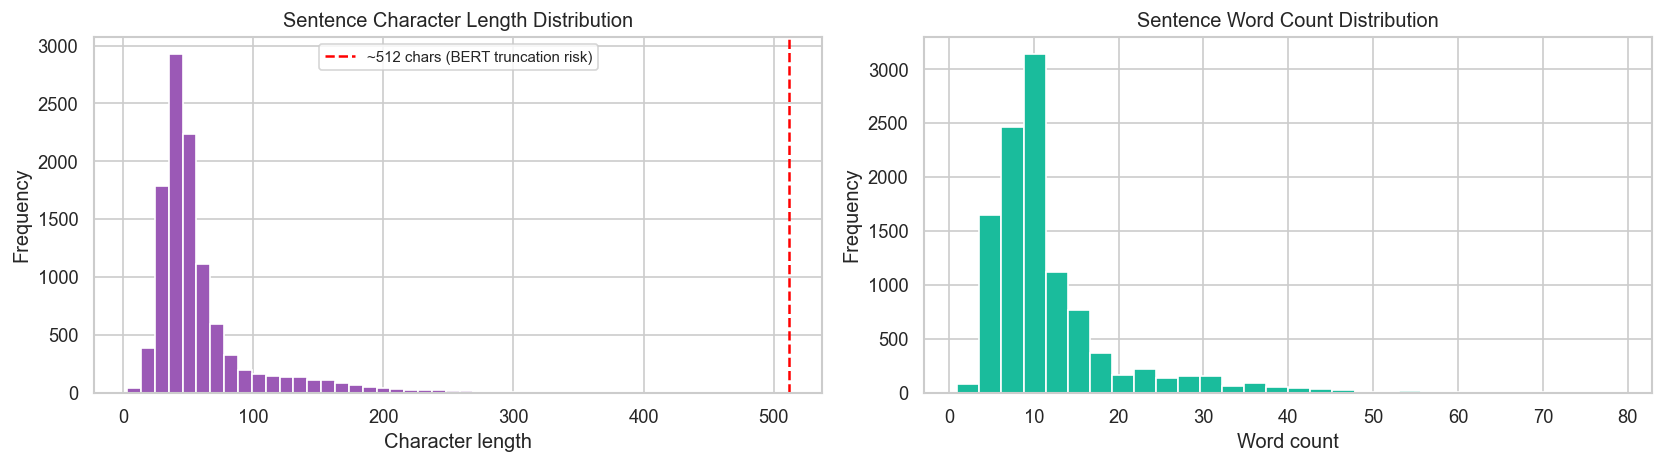

Sentences over 512 chars (truncation risk): 0 (0.00%)
Most sentences are short — BERT truncation is not a concern for this dataset.


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character length distribution — we mark the 512-char line as a rough BERT truncation indicator
axes[0].hist(train_df['char_length'], bins=40, color='#9b59b6', edgecolor='white')
axes[0].axvline(512, color='red', linestyle='--', label='~512 chars (BERT truncation risk)')
axes[0].set_xlabel('Character length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sentence Character Length Distribution')
axes[0].legend(fontsize=9)

# Word count distribution
axes[1].hist(train_df['word_count'], bins=30, color='#1abc9c', edgecolor='white')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sentence Word Count Distribution')

plt.tight_layout()
plt.show()

over_512 = (train_df['char_length'] > 512).sum()
print(f'Sentences over 512 chars (truncation risk): {over_512} ({over_512/len(train_df)*100:.2f}%)')
print('Most sentences are short — BERT truncation is not a concern for this dataset.')

In [61]:
# Which categories tend to use longer sentences?
avg_len = train_df.groupby('category')['word_count'].mean().sort_values(ascending=False)

top10    = avg_len.head(10).reset_index()
bottom10 = avg_len.tail(10).reset_index()
top10.columns    = ['Category', 'Avg word count']
bottom10.columns = ['Category', 'Avg word count']
top10['Avg word count']    = top10['Avg word count'].round(1)
bottom10['Avg word count'] = bottom10['Avg word count'].round(1)

styled(top10, caption="Top 10 categories by average word count (longest sentences)")

,Category,Avg word count
0,transfer_not_received_by_recipient,17.500000
1,transfer_fee_charged,17.400000
2,pending_cash_withdrawal,16.500000
3,failed_transfer,16.000000
4,direct_debit_payment_not_recognised,16.000000
5,transaction_charged_twice,16.000000
6,Refund_not_showing_up,15.800000
7,wrong_exchange_rate_for_cash_withdrawal,15.500000
8,cash_withdrawal_not_recognised,15.400000
9,wrong_amount_of_cash_received,15.300000


In [62]:
styled(bottom10, caption="Bottom 10 categories by average word count (shortest sentences)")

,Category,Avg word count
0,verify_top_up,8.300000
1,visa_or_mastercard,8.200000
2,top_up_limits,8.000000
3,get_physical_card,8.000000
4,exchange_rate,8.000000
5,atm_support,7.900000
6,passcode_forgotten,7.900000
7,order_physical_card,7.900000
8,card_acceptance,7.300000
9,neutral,4.600000


In [64]:
# save new cleaned datasets after cleaning and duplicate removal
train_df.to_csv('../data/train_final.csv', index=False)
test_df.to_csv('../data/test_final.csv', index=False)